# Project 10 (Notebook 2/3) - PBMC 3k pipeline in Seurat (R)

**Same dataset and same parameters as notebook 1** (Scanpy). The goal is to run an identical workflow in the R / Seurat ecosystem and save outputs in the same format so the comparison notebook can directly compute cross-platform metrics.

**Pipeline:** CreateSeuratObject -> filter -> NormalizeData -> FindVariableFeatures -> ScaleData -> RunPCA -> FindNeighbors -> FindClusters -> RunUMAP -> FindAllMarkers -> annotate.

## 1. Setup

In [1]:
suppressPackageStartupMessages({
  library(Seurat)
  library(SeuratObject)
  library(anndata)
  library(tidyverse)
  library(patchwork)
  library(Matrix)
  library(jsonlite)
})

set.seed(42)
options(stringsAsFactors = FALSE)

FIG_DIR <- '../figures'
RES_DIR <- '../results'
dir.create(FIG_DIR, showWarnings = FALSE, recursive = TRUE)
dir.create(RES_DIR, showWarnings = FALSE, recursive = TRUE)

save_fig <- function(p, path, w = 8, h = 6, dpi = 300) {
  ggsave(path, plot = p, width = w, height = h, dpi = dpi, bg = 'white')
}

cat('Seurat:       ', as.character(packageVersion('Seurat')), '\n')
cat('SeuratObject: ', as.character(packageVersion('SeuratObject')), '\n')

Seurat:        5.3.0 


SeuratObject:  5.2.0 


## 2. Load raw counts from the same h5ad as Python notebook

In [2]:
ad <- read_h5ad('/home/marko-b2/upwork_portfolio/01_pbmc3k_basics/notebooks/data/pbmc3k_raw.h5ad')
cat('AnnData shape:', dim(ad), '\n')

# Convert to dgCMatrix, genes x cells (Seurat convention)
X <- ad$X
if (!inherits(X, 'dgCMatrix')) {
  X <- as(X, 'CsparseMatrix')
}
counts <- Matrix::t(X)
rownames(counts) <- ad$var_names
colnames(counts) <- ad$obs_names
# De-duplicate gene names (Seurat does this automatically too)
rownames(counts) <- make.unique(rownames(counts))

cat('counts matrix:', dim(counts)[1], 'genes x', dim(counts)[2], 'cells\n')
cat('max value:', max(counts), '(should be raw counts >>50)\n')

obj <- CreateSeuratObject(counts = counts, project = 'pbmc3k', min.cells = 3, min.features = 200)
cat('After CreateSeuratObject:\n')
print(obj)

AnnData shape: 2700 32738 


counts matrix: 32738 genes x 2700 cells


max value: 419 (should be raw counts >>50)


Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


After CreateSeuratObject:


An object of class Seurat 
13714 features across 2700 samples within 1 assay 
Active assay: RNA (13714 features, 0 variable features)
 1 layer present: counts


## 3. QC filter (matching Scanpy: min_cells=3 done in step 2, min_genes=200 done in step 2, pct_mito<5%)

In [3]:
t0 <- Sys.time()
obj[['percent.mt']] <- PercentageFeatureSet(obj, pattern = '^MT-')
cat('Before pct_mito filter:', ncol(obj), 'cells\n')
obj <- subset(obj, subset = percent.mt < 5)
cat('After pct_mito<5% filter:', ncol(obj), 'cells, ', nrow(obj), 'genes\n')
qc_time <- as.numeric(Sys.time() - t0, units = 'secs')
cat('QC step:', round(qc_time, 1), 's\n')

Before pct_mito filter: 2700 cells


After pct_mito<5% filter: 2643 cells,  13714 genes


QC step: 0.1 s


## 4. Normalize + HVG + Scale + PCA

In [4]:
t0 <- Sys.time()
obj <- NormalizeData(obj, normalization.method = 'LogNormalize', scale.factor = 10000, verbose = FALSE)
obj <- FindVariableFeatures(obj, selection.method = 'vst', nfeatures = 2000, verbose = FALSE)
obj <- ScaleData(obj, features = VariableFeatures(obj), verbose = FALSE)
obj <- RunPCA(obj, features = VariableFeatures(obj), npcs = 50, seed.use = 42, verbose = FALSE)
prep_time <- as.numeric(Sys.time() - t0, units = 'secs')
cat('Preprocessing:', round(prep_time, 1), 's\n')
cat('HVGs:', length(VariableFeatures(obj)), '\n')
cat('PCA dim:', dim(Embeddings(obj, 'pca')), '\n')

Preprocessing: 2 s


HVGs: 2000 


PCA dim: 2643 50 


## 5. Neighbors + Clusters + UMAP

In [5]:
t0 <- Sys.time()
obj <- FindNeighbors(obj, dims = 1:30, k.param = 15, verbose = FALSE)
obj <- FindClusters(obj, resolution = 0.5, random.seed = 42, verbose = FALSE)
obj <- RunUMAP(obj, dims = 1:30, seed.use = 42, verbose = FALSE)
umap_time <- as.numeric(Sys.time() - t0, units = 'secs')
cat('Neighbors+Clusters+UMAP:', round(umap_time, 1), 's\n')
cat('Number of clusters:', length(levels(Idents(obj))), '\n')
print(table(Idents(obj)))

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


Neighbors+Clusters+UMAP: 3.5 s


Number of clusters: 8 



   0    1    2    3    4    5    6    7 
1167  478  347  282  162  162   31   14 


## 6. Marker genes

In [6]:
t0 <- Sys.time()
markers_all <- FindAllMarkers(obj, only.pos = TRUE, min.pct = 0.25, logfc.threshold = 0.25, verbose = FALSE)
marker_time <- as.numeric(Sys.time() - t0, units = 'secs')
cat('FindAllMarkers:', round(marker_time, 1), 's\n')

# Top 50 per cluster
markers_top <- markers_all %>%
  group_by(cluster) %>%
  arrange(desc(avg_log2FC), .by_group = TRUE) %>%
  mutate(rank = row_number()) %>%
  filter(rank <= 50) %>%
  ungroup() %>%
  select(cluster, rank, gene, score = avg_log2FC, pval = p_val, pval_adj = p_val_adj, logfc = avg_log2FC)

write.csv(markers_top, file.path(RES_DIR, 'r_markers_top50.csv'), row.names = FALSE)
cat('Saved markers:', nrow(markers_top), 'rows\n')

cat('\nTop 5 markers per cluster:\n')
for (cl in sort(as.integer(as.character(unique(markers_top$cluster))))) {
  top5 <- markers_top %>% filter(cluster == cl) %>% head(5) %>% pull(gene)
  cat(sprintf('  Cluster %s: %s\n', cl, paste(top5, collapse = ', ')))
}

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


FindAllMarkers: 1.5 s


Saved markers: 400 rows



Top 5 markers per cluster:


  Cluster 0: MAL, LEF1, AQP3, CCR7, PRKCQ-AS1
  Cluster 1: FOLR3, S100A12, S100A8, S100A9, CD14
  Cluster 2: LINC00926, VPREB3, CD79A, TCL1A, FCRLA
  Cluster 3: GZMK, GZMH, CD8A, CCL5, KLRG1
  Cluster 4: CKB, CDKN1C, MS4A4A, HES4, BATF3
  Cluster 5: AKR1C3, SH2D1B, GNLY, GZMB, XCL1
  Cluster 6: FCER1A, CLIC2, CLEC10A, ENHO, SERPINF1
  Cluster 7: LY6G6F, RP11-879F14.2, CLDN5, GP9, AP001189.4


## 7. Cell-type annotation (same logic as Python)

In [7]:
marker_signatures <- list(
  `CD4 T`        = c('IL7R','CCR7','TCF7','LTB'),
  `CD8 T`        = c('CD8A','CD8B','GZMK'),
  `NK`           = c('GNLY','NKG7','FCGR3A','GZMB','PRF1'),
  `B`            = c('MS4A1','CD79A','CD79B','IGHM','CD19'),
  `Mono CD14`    = c('CD14','LYZ','S100A8','S100A9'),
  `Mono FCGR3A`  = c('FCGR3A','MS4A7','CDKN1C'),
  `DC`           = c('FCER1A','CST3','CLEC10A'),
  `Platelet`     = c('PPBP','PF4','ITGA2B')
)

# Build cluster-to-label by max signature overlap
cluster_ids <- sort(as.integer(as.character(unique(markers_top$cluster))))
cluster_to_label <- character(length(cluster_ids))
names(cluster_to_label) <- as.character(cluster_ids)

for (cl in cluster_ids) {
  cl_markers <- markers_top %>% filter(cluster == cl) %>% head(30) %>% pull(gene)
  scores <- sapply(marker_signatures, function(sig) length(intersect(sig, cl_markers)))
  best <- names(which.max(scores))
  if (scores[best] == 0) best <- paste0('Unknown_', cl)
  cluster_to_label[as.character(cl)] <- best
}

# Disambiguate duplicates by appending cluster id
label_counts <- table(cluster_to_label)
dup_labels <- names(label_counts[label_counts > 1])
for (lab in dup_labels) {
  clusters_w_lab <- names(cluster_to_label)[cluster_to_label == lab]
  for (c in clusters_w_lab) {
    cluster_to_label[c] <- paste0(lab, '_', c)
  }
}

# Now map to obj$celltype via simple lookup (avoids RenameIdents pitfall)
obj$celltype <- factor(unname(cluster_to_label[as.character(obj$seurat_clusters)]))

cat('Final cluster -> celltype mapping:\n')
for (cl in cluster_ids) {
  cat(sprintf('  %s: %s\n', cl, cluster_to_label[as.character(cl)]))
}
cat('\nCell-type counts:\n')
print(table(obj$celltype))


Final cluster -> celltype mapping:


  0: CD4 T
  1: Mono CD14
  2: B
  3: CD8 T
  4: Mono FCGR3A
  5: NK
  6: DC
  7: Platelet



Cell-type counts:



          B       CD4 T       CD8 T          DC   Mono CD14 Mono FCGR3A 
        347        1167         282          31         478         162 
         NK    Platelet 
        162          14 


## 8. Hero figure: UMAP by cluster + UMAP by celltype

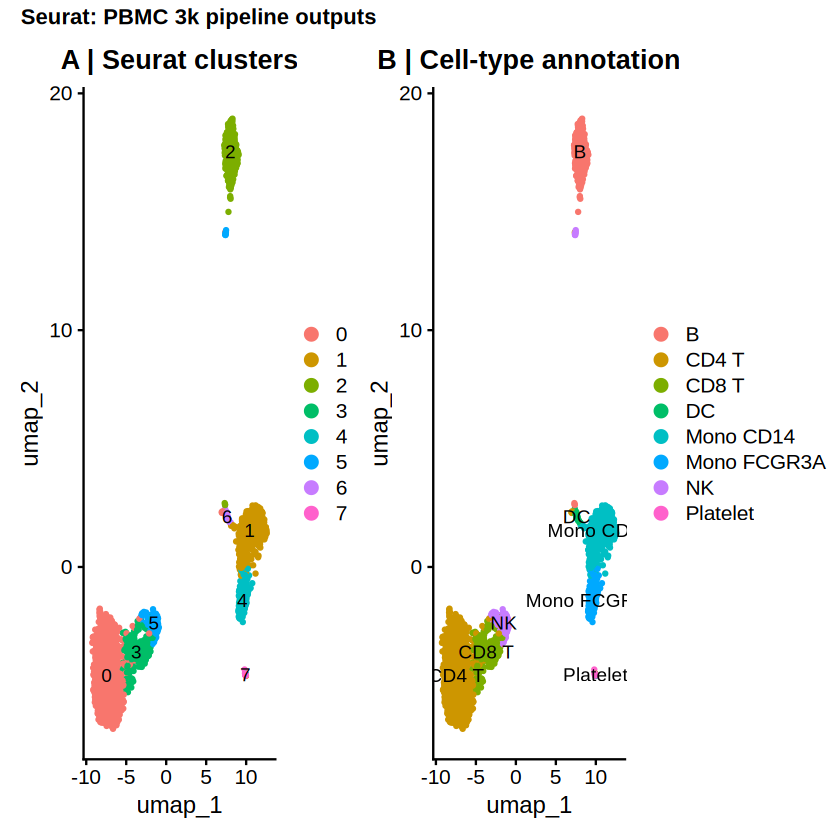

In [8]:
p_clust <- DimPlot(obj, reduction = 'umap', group.by = 'seurat_clusters', label = TRUE, label.size = 4) +
  ggtitle('A | Seurat clusters') + theme(legend.position = 'right', plot.title = element_text(face='bold'))
p_ctype <- DimPlot(obj, reduction = 'umap', group.by = 'celltype', label = TRUE, label.size = 4) +
  ggtitle('B | Cell-type annotation') + theme(legend.position = 'right', plot.title = element_text(face='bold'))

p <- p_clust + p_ctype + plot_annotation(title = 'Seurat: PBMC 3k pipeline outputs',
                                          theme = theme(plot.title = element_text(face='bold', size=13)))
save_fig(p, file.path(FIG_DIR, 'r_umap.png'), w = 13, h = 5.5)
print(p)

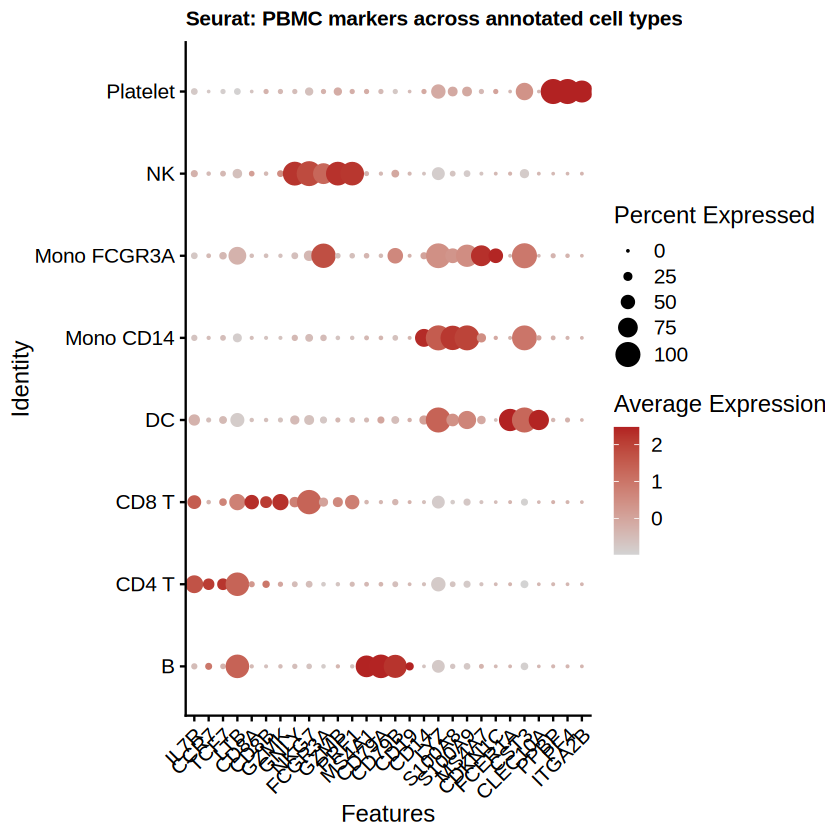

In [9]:
marker_flat <- unique(unlist(marker_signatures))
marker_flat <- marker_flat[marker_flat %in% rownames(obj)]

p_dot <- DotPlot(obj, features = marker_flat, group.by = 'celltype', cols = c('lightgrey','firebrick')) +
  RotatedAxis() +
  ggtitle('Seurat: PBMC markers across annotated cell types') +
  theme(plot.title = element_text(face = 'bold', size = 12))
save_fig(p_dot, file.path(FIG_DIR, 'r_marker_dotplot.png'), w = max(8, 0.45 * length(marker_flat)), h = 5)
print(p_dot)

## 9. Save outputs for the comparison notebook

In [10]:
umap_coords <- Embeddings(obj, 'umap')
pca_coords <- Embeddings(obj, 'pca')

per_cell <- data.frame(
  cell = colnames(obj),
  seurat_cluster = as.character(obj$seurat_clusters),
  celltype = as.character(obj$celltype),
  UMAP1 = umap_coords[, 1],
  UMAP2 = umap_coords[, 2]
)
for (i in 1:min(30, ncol(pca_coords))) {
  per_cell[[paste0('PC', i)]] <- pca_coords[, i]
}
write.csv(per_cell, file.path(RES_DIR, 'r_per_cell.csv'), row.names = FALSE)

saveRDS(obj, file.path(RES_DIR, 'r_pbmc3k_processed.rds'))

summary_list <- list(
  ecosystem = 'Seurat (R)',
  seurat_version = as.character(packageVersion('Seurat')),
  n_cells_after_qc = ncol(obj),
  n_genes_after_qc = nrow(obj),
  n_hvg = length(VariableFeatures(obj)),
  n_pcs = 50,
  n_seurat_clusters = length(levels(obj$seurat_clusters)),
  cluster_sizes = as.list(table(obj$seurat_clusters)),
  cluster_to_celltype = as.list(cluster_to_label),
  celltypes = sort(unique(as.character(obj$celltype))),
  runtime_sec = list(
    qc = qc_time,
    preprocessing = prep_time,
    umap_clustering = umap_time,
    marker_genes = marker_time,
    total = qc_time + prep_time + umap_time + marker_time
  ),
  seed = 42
)
write_json(summary_list, file.path(RES_DIR, 'r_summary.json'), pretty = TRUE, auto_unbox = TRUE)

cat('Saved:\n')
cat(' ', file.path(RES_DIR, 'r_per_cell.csv'), '\n')
cat(' ', file.path(RES_DIR, 'r_pbmc3k_processed.rds'), '\n')
cat(' ', file.path(RES_DIR, 'r_summary.json'), '\n')
cat(' ', file.path(RES_DIR, 'r_markers_top50.csv'), '\n')
cat(sprintf('\nTotal pipeline time: %.1fs\n', summary_list$runtime_sec$total))


Saved:


  ../results/r_per_cell.csv 


  ../results/r_pbmc3k_processed.rds 


  ../results/r_summary.json 


  ../results/r_markers_top50.csv 



Total pipeline time: 7.2s
